# Complete Business EDA Notebook

This notebook performs a complete, presentation-ready exploratory data analysis of the available product intelligence CSV datasets. It auto-detects files, columns, and data types; profiles data quality; analyzes product, category, brand, channel, campaign, acquisition, and time-series performance; models KPI drivers; investigates root-cause hypotheses for KPI drops; and ranks business recommendations by impact.

All analysis, outputs, tables, insights, and visualizations are rendered inline in this notebook. No separate chart, image, or output files are saved.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"

ROOT = Path.cwd()
RANDOM_STATE = 42


def note(text):
    display(Markdown(text))


def clean_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def load_csv(path):
    data = pd.read_csv(path)
    data.columns = [clean_name(c) for c in data.columns]
    for col in data.columns:
        if ("date" in col or col in {"day", "week", "month"}) and data[col].dtype == "object":
            parsed = pd.to_datetime(data[col], errors="coerce")
            if parsed.notna().mean() >= 0.6:
                data[col] = parsed
    return data


def infer_roles(data):
    roles = {k: [] for k in ["date", "numeric", "categorical", "boolean", "id", "json_like", "constant", "near_constant"]}
    for col in data.columns:
        s = data[col]
        low = col.lower()
        if pd.api.types.is_datetime64_any_dtype(s):
            roles["date"].append(col)
        elif pd.api.types.is_bool_dtype(s):
            roles["boolean"].append(col)
        elif pd.api.types.is_numeric_dtype(s):
            roles["numeric"].append(col)
        else:
            roles["categorical"].append(col)
            sample = s.dropna().astype(str).head(50)
            if len(sample) and sample.str.match(r"^\s*[\{\[]").mean() > 0.4:
                roles["json_like"].append(col)
        if low.endswith("_id") or low in {"id", "product_id", "customer_id", "trajectory_id", "schedule_id"}:
            roles["id"].append(col)
        nunique = s.nunique(dropna=True)
        if nunique <= 1:
            roles["constant"].append(col)
        elif len(s) and s.value_counts(dropna=False, normalize=True).iloc[0] >= 0.98:
            roles["near_constant"].append(col)
    return roles


def iqr_outlier_mask(s):
    x = pd.to_numeric(s, errors="coerce")
    y = x.dropna()
    if len(y) < 8:
        return pd.Series(False, index=s.index)
    q1, q3 = y.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0 or pd.isna(iqr):
        return pd.Series(False, index=s.index)
    return (x < q1 - 1.5 * iqr) | (x > q3 + 1.5 * iqr)


def business_impact(col):
    c = col.lower()
    if any(k in c for k in ["revenue", "profit", "orders", "conversion", "retention", "ltv", "roas"]):
        return "High: KPI reliability, forecasting, and executive reporting can be distorted."
    if any(k in c for k in ["product", "category", "brand", "channel", "campaign", "source"]):
        return "Medium-high: segmentation and budget or portfolio decisions may be biased."
    if any(k in c for k in ["date", "day", "time"]):
        return "High: trend, experiment, and root-cause timing can be misread."
    return "Medium: may affect profiling, model features, or operational interpretation."


def performance_table(data, dims, top_n=15):
    dims = [d for d in dims if d in data.columns]
    if not dims:
        return pd.DataFrame()
    agg = {}
    for c in ["revenue", "profit", "orders", "traffic", "marketing_spend"]:
        if c in data.columns:
            agg[c] = "sum"
    for c in ["conversion_rate", "retention_rate", "avg_ltv", "current_roas"]:
        if c in data.columns:
            agg[c] = "mean"
    table = data.groupby(dims, dropna=False).agg(agg).reset_index()
    if "revenue" in table:
        table["revenue_share_%"] = table["revenue"] / table["revenue"].sum() * 100
    if {"profit", "revenue"} <= set(table.columns):
        table["profit_margin_%"] = np.where(table["revenue"] != 0, table["profit"] / table["revenue"] * 100, np.nan)
    if {"revenue", "marketing_spend"} <= set(table.columns):
        table["computed_roas"] = np.where(table["marketing_spend"] != 0, table["revenue"] / table["marketing_spend"], np.nan)
    sort_col = "profit" if "profit" in table else "revenue" if "revenue" in table else table.columns[-1]
    return table.sort_values(sort_col, ascending=False).head(top_n)


def contribution_analysis(data, pct_cols, label):
    pct_cols = [c for c in pct_cols if c in data.columns]
    if not pct_cols:
        note(f"No {label.lower()} percentage columns were found.")
        return pd.DataFrame()
    rows = []
    for col in pct_cols:
        name = col
        for suffix in ["_sales_pct", "_campaign_pct", "_source_pct", "sales_mix_", "campaign_mix_", "acq_mix_"]:
            name = name.replace(suffix, "")
        pct = data[col].fillna(0)
        factor = pct / (100 if pct.max() > 1.5 else 1)
        row = {"segment": name, "avg_mix_%": factor.mean() * 100}
        for kpi in ["revenue", "profit", "orders", "traffic", "marketing_spend"]:
            if kpi in data.columns:
                row[f"estimated_{kpi}"] = (data[kpi].fillna(0) * factor).sum()
        if "estimated_revenue" in row and "estimated_marketing_spend" in row and row["estimated_marketing_spend"]:
            row["estimated_roas"] = row["estimated_revenue"] / row["estimated_marketing_spend"]
        rows.append(row)
    result = pd.DataFrame(rows)
    sort_col = "estimated_profit" if "estimated_profit" in result else "estimated_revenue"
    result = result.sort_values(sort_col, ascending=False)
    display(result)
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(data=result, x="segment", y=sort_col, ax=ax, color="#3A5A40")
    ax.set_title(f"{label}: estimated {sort_col.replace('estimated_', '')} contribution")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    plt.show()
    top = result.iloc[0]
    note(f"**Finding:** `{top.segment}` has the strongest estimated {sort_col.replace('estimated_', '')} contribution. **Action:** compare its conversion and retention quality before scaling investment; channels with high contribution but weak ROAS should be optimized before they receive more budget.")
    return result

## 1. Data Discovery and Automatic Type Detection

In [2]:
csv_paths = sorted(p for p in ROOT.rglob("*.csv") if ".git" not in p.parts)
loaded = {}
for path in csv_paths:
    try:
        loaded[str(path.relative_to(ROOT))] = load_csv(path)
    except Exception as exc:
        note(f"**Skipped `{path}`:** {exc}")

if not loaded:
    raise FileNotFoundError("No CSV files were found in the repository.")

inventory = []
for name, data in loaded.items():
    cols = set(data.columns)
    inventory.append({
        "dataset": name,
        "rows": len(data),
        "columns": data.shape[1],
        "kpi_columns_found": len(cols & {"revenue", "profit", "orders", "traffic", "conversion_rate", "retention_rate", "marketing_spend", "avg_ltv"}),
        "business_dimensions_found": len(cols & {"product_id", "category", "subcategory", "brand", "date"}),
        "experiment_columns_found": len(cols & {"experiment_id", "experiment_type", "start_date", "end_date", "primary_metric", "observed_effect_pct"}),
        "memory_mb": data.memory_usage(deep=True).sum() / 1_000_000,
    })
inventory_df = pd.DataFrame(inventory).sort_values(["kpi_columns_found", "business_dimensions_found", "rows"], ascending=False)
display(inventory_df)

main_dataset_name = inventory_df.iloc[0]["dataset"]
df = loaded[main_dataset_name].copy()
roles = infer_roles(df)
experiment_candidates = [name for name, data in loaded.items() if len(set(data.columns) & {"experiment_id", "experiment_type", "start_date", "end_date"}) >= 2]
display(pd.DataFrame([{"role": k, "count": len(v), "columns": ", ".join(v[:18]) + (" ..." if len(v) > 18 else "")} for k, v in roles.items()]))
note(f"**Primary dataset selected:** `{main_dataset_name}` with **{len(df):,} rows** and **{df.shape[1]:,} columns**. Column roles were inferred from values and names, so the analysis can adapt when the dataset changes.")
if experiment_candidates:
    note("**Experiment dataset(s) detected:** " + ", ".join(f"`{x}`" for x in experiment_candidates))
else:
    note("**Experiment dataset detected:** none in the current working tree. The experiment section will document this limitation and continue.")

,dataset,rows,columns,kpi_columns_found,business_dimensions_found,experiment_columns_found,memory_mb
0,backend\temporal_dataset.csv,36500,38,8,5,0,21.6281
2,new\data-generator\code\final-output\trajector...,87600,39,8,1,0,33.9889
1,new\data-generator\code\final-output\training_...,87360,55,8,1,0,45.0779


,role,count,columns
0,date,0,
1,numeric,29,"avg_ltv, inventory_available, avg_selling_pric..."
2,categorical,9,"date, product_id, category, subcategory, brand..."
3,boolean,0,
4,id,1,product_id
5,json_like,3,"sales_channel_mix, campaign_mix, acquisition_mix"
6,constant,0,
7,near_constant,0,


**Primary dataset selected:** `backend\temporal_dataset.csv` with **36,500 rows** and **38 columns**. Column roles were inferred from values and names, so the analysis can adapt when the dataset changes.

**Experiment dataset detected:** none in the current working tree. The experiment section will document this limitation and continue.

## 2. Data Quality Summary with Business Impact

In [3]:
quality = []
for col in df.columns:
    s = df[col]
    row = {
        "column": col,
        "dtype": str(s.dtype),
        "missing_%": s.isna().mean() * 100,
        "unique_values": s.nunique(dropna=True),
        "constant": s.nunique(dropna=True) <= 1,
        "near_constant": bool(len(s) and s.value_counts(dropna=False, normalize=True).iloc[0] >= 0.98),
        "business_impact": business_impact(col),
    }
    if pd.api.types.is_numeric_dtype(s):
        row["outlier_%_iqr"] = iqr_outlier_mask(s).mean() * 100
        x = s.dropna()
        if any(k in col for k in ["rate", "pct", "mix"]):
            upper = 100 if x.max() > 1.5 else 1
            row["invalid_%"] = ((x < 0) | (x > upper)).mean() * 100
        elif any(k in col for k in ["revenue", "orders", "traffic", "users", "spend", "price", "inventory", "ltv"]):
            row["invalid_%"] = (x < 0).mean() * 100
        else:
            row["invalid_%"] = np.nan
    else:
        row["outlier_%_iqr"] = np.nan
        row["invalid_%"] = np.nan
    quality.append(row)
quality_df = pd.DataFrame(quality).sort_values(["missing_%", "invalid_%", "outlier_%_iqr"], ascending=False)
display(quality_df)
display(pd.DataFrame({
    "metric": ["Rows", "Columns", "Exact duplicate rows", "Columns with missing values", "Constant columns", "Near-constant columns", "Numeric columns with >5% IQR outliers"],
    "value": [len(df), df.shape[1], df.duplicated().sum(), int((df.isna().mean() > 0).sum()), len(roles["constant"]), len(roles["near_constant"]), int((quality_df["outlier_%_iqr"].fillna(0) > 5).sum())]
}))
note("**Business interpretation:** Quality issues in KPI fields can distort forecasting and budget allocation. Outliers are flagged, not deleted, because in commerce data they often represent promotions, stockouts, tracking breaks, or campaign spikes.")

,column,dtype,missing_%,unique_values,constant,near_constant,business_impact,outlier_%_iqr,invalid_%
30,active_users,int64,0.0000,2253,False,False,"Medium: may affect profiling, model features, ...",4.5452,0.0000
33,orders,int64,0.0000,172,False,False,"High: KPI reliability, forecasting, and execut...",4.3534,0.0000
29,traffic,int64,0.0000,5924,False,False,"Medium: may affect profiling, model features, ...",4.2521,0.0000
34,revenue,float64,0.0000,36325,False,False,"High: KPI reliability, forecasting, and execut...",4.1315,0.0000
27,referral_source_pct,float64,0.0000,111,False,False,Medium-high: segmentation and budget or portfo...,4.0000,0.0000
28,marketing_spend,int64,0.0000,10411,False,False,"Medium: may affect profiling, model features, ...",3.3973,0.0000
21,affiliate_campaign_pct,float64,0.0000,195,False,False,Medium-high: segmentation and budget or portfo...,3.1425,0.0000
25,email_source_pct,float64,0.0000,95,False,False,Medium-high: segmentation and budget or portfo...,3.0000,0.0000
16,nykaa_sales_pct,float64,0.0000,203,False,False,"Medium: may affect profiling, model features, ...",2.6548,0.0000
9,discount_pct,int64,0.0000,40,False,False,"Medium: may affect profiling, model features, ...",2.3288,0.0000


,metric,value
0,Rows,36500
1,Columns,38
2,Exact duplicate rows,0
3,Columns with missing values,0
4,Constant columns,0
5,Near-constant columns,0
6,Numeric columns with >5% IQR outliers,0


**Business interpretation:** Quality issues in KPI fields can distort forecasting and budget allocation. Outliers are flagged, not deleted, because in commerce data they often represent promotions, stockouts, tracking breaks, or campaign spikes.

## 3. Numeric Distributions, Summary Stats, Skewness, and Interpretation

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_%,skewness,outlier_%_iqr
revenue,"36,500.0000","21,128.4942","15,142.5808","2,347.7800","4,257.6539","5,692.4830","10,098.0775","17,160.2800","27,598.3575","50,344.1905","74,850.5489","208,544.8400",0.0000,1.9419,4.1315
profit,"36,500.0000","3,397.2124","6,874.7157","-16,241.0500","-7,034.8784","-4,541.1225","-1,055.0150","1,876.6550","6,429.9400","15,834.1105","28,199.7795","99,537.2300",0.0000,1.9235,3.8164
orders,"36,500.0000",38.3965,20.8889,6.0000,11.0000,15.0000,24.0000,33.0000,47.0000,79.0000,114.0000,252.0000,0.0000,1.7129,4.3534
traffic,"36,500.0000","3,222.5382","1,394.1637",913.0000,"1,322.9900","1,617.0000","2,303.0000","2,907.0000","3,806.0000","5,804.1000","8,513.0200","13,252.0000",0.0000,1.8181,4.2521
active_users,"36,500.0000",892.0968,391.8774,243.0000,374.0000,452.0000,636.0000,801.0000,"1,048.0000","1,623.0500","2,397.0100","3,962.0000",0.0000,1.9258,4.5452
marketing_spend,"36,500.0000","7,465.8042","3,199.1735","1,580.0000","2,729.9800","3,578.0000","5,214.0000","6,880.0000","8,971.0000","13,451.0000","18,817.0600","30,222.0000",0.0000,1.3999,3.3973
conversion_rate,"36,500.0000",0.0425,0.0112,0.0182,0.0223,0.0254,0.0344,0.0412,0.0496,0.0627,0.0704,0.0948,0.0000,0.4761,0.6137
retention_rate,"36,500.0000",0.3348,0.0776,0.1745,0.1896,0.2034,0.2790,0.3325,0.3856,0.4667,0.5056,0.5655,0.0000,0.1187,0.0110
current_roas,"36,500.0000",2.8771,1.7006,0.5630,0.7930,0.9680,1.6670,2.4650,3.6822,6.1770,8.9000,14.7870,0.0000,1.5801,3.8164
avg_ltv,"36,500.0000","2,426.7172","1,081.6723",631.0000,830.9900,"1,024.9500","1,590.0000","2,227.0000","3,090.0000","4,517.0500","5,521.0300","6,536.0000",0.0000,0.8256,1.5973


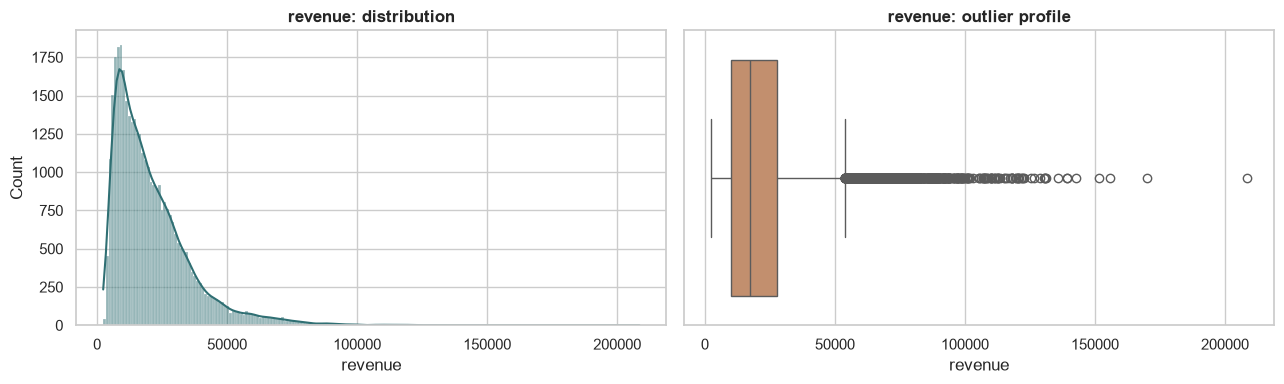

**Finding for `revenue`:** The distribution is **right-skewed** with skewness **1.94** and **4.1%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

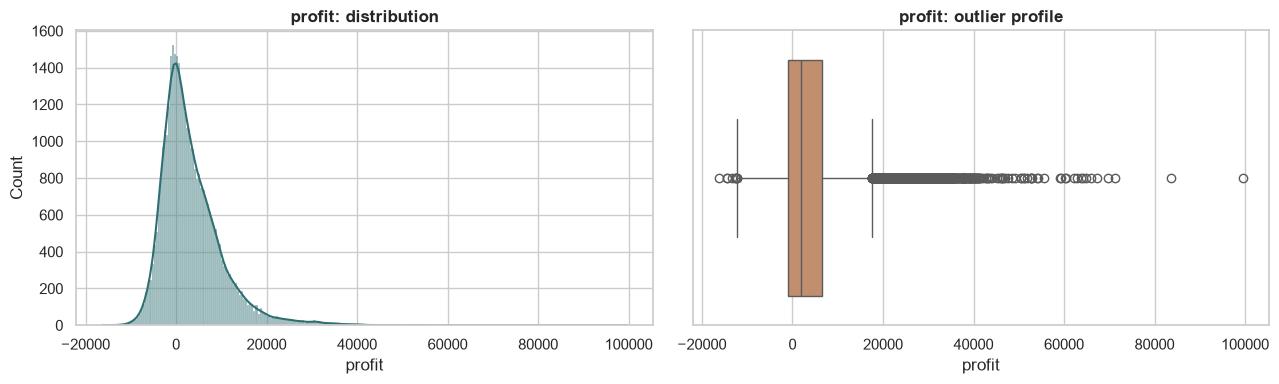

**Finding for `profit`:** The distribution is **right-skewed** with skewness **1.92** and **3.8%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

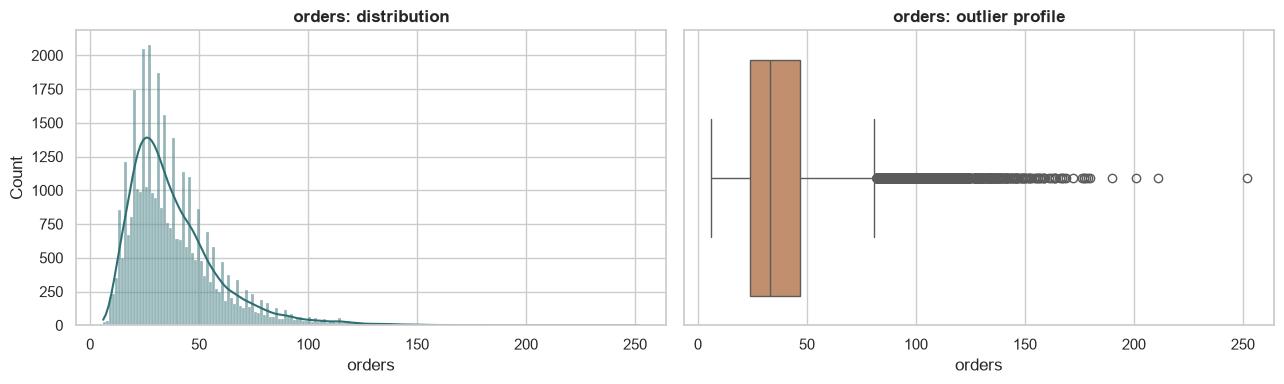

**Finding for `orders`:** The distribution is **right-skewed** with skewness **1.71** and **4.4%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

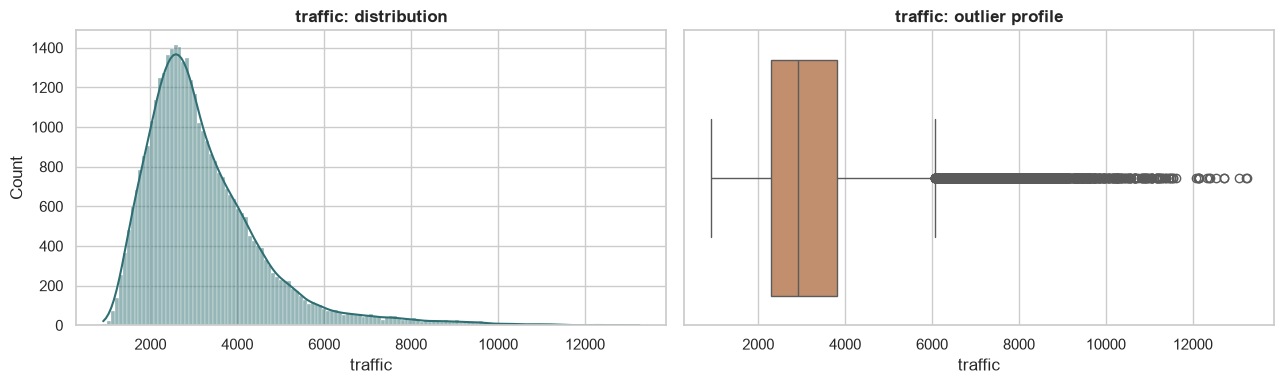

**Finding for `traffic`:** The distribution is **right-skewed** with skewness **1.82** and **4.3%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

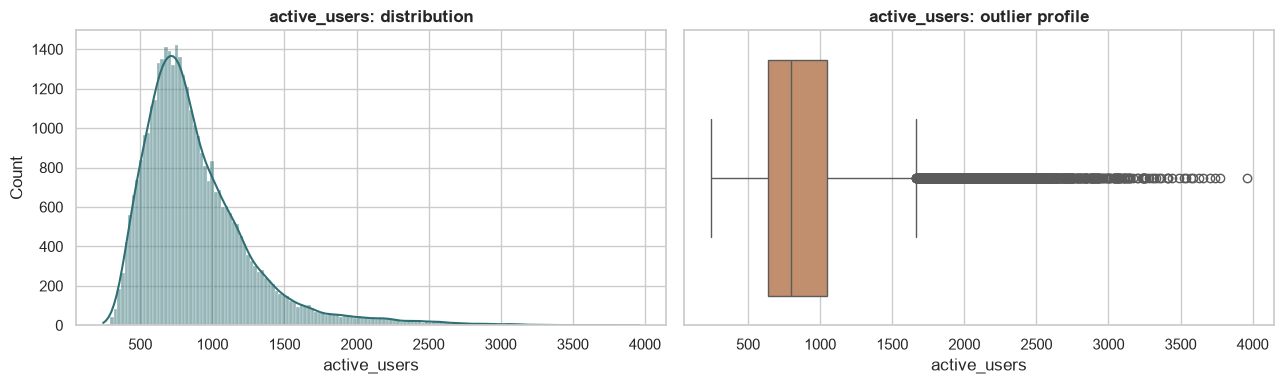

**Finding for `active_users`:** The distribution is **right-skewed** with skewness **1.93** and **4.5%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

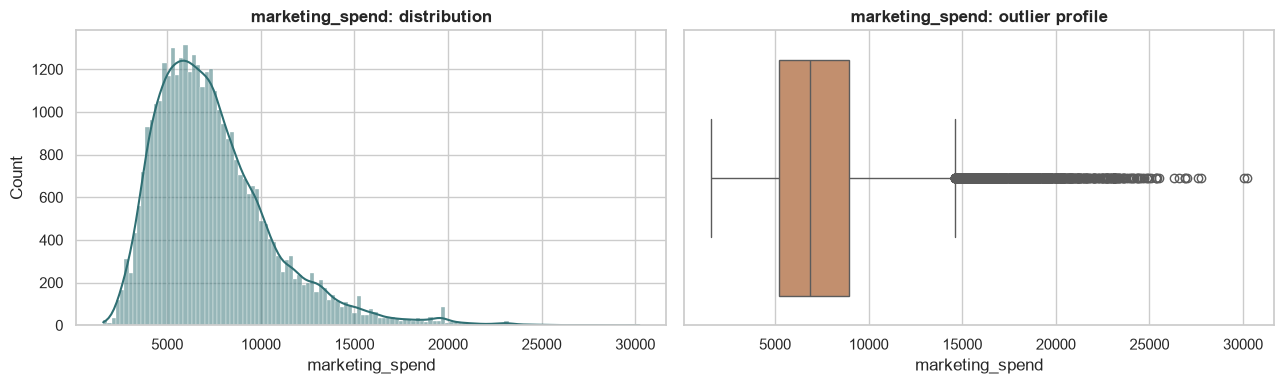

**Finding for `marketing_spend`:** The distribution is **right-skewed** with skewness **1.40** and **3.4%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

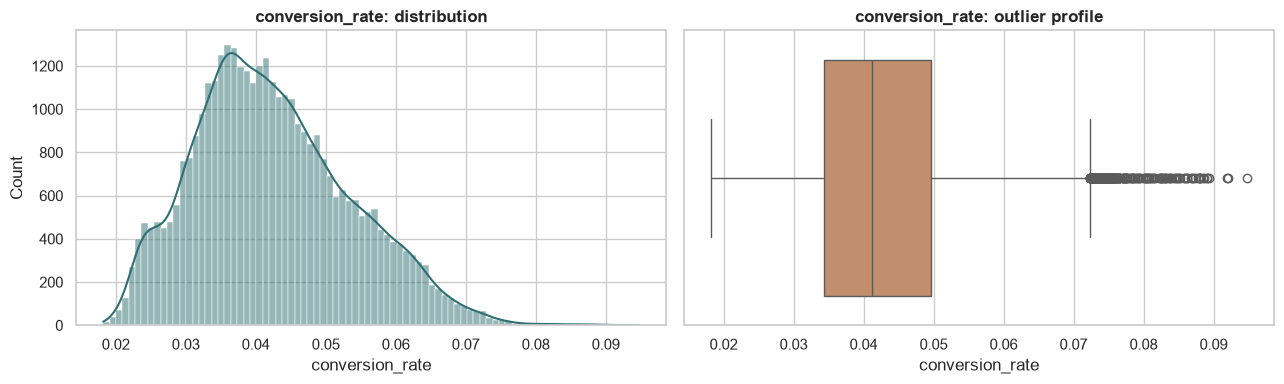

**Finding for `conversion_rate`:** The distribution is **fairly balanced** with skewness **0.48** and **0.6%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

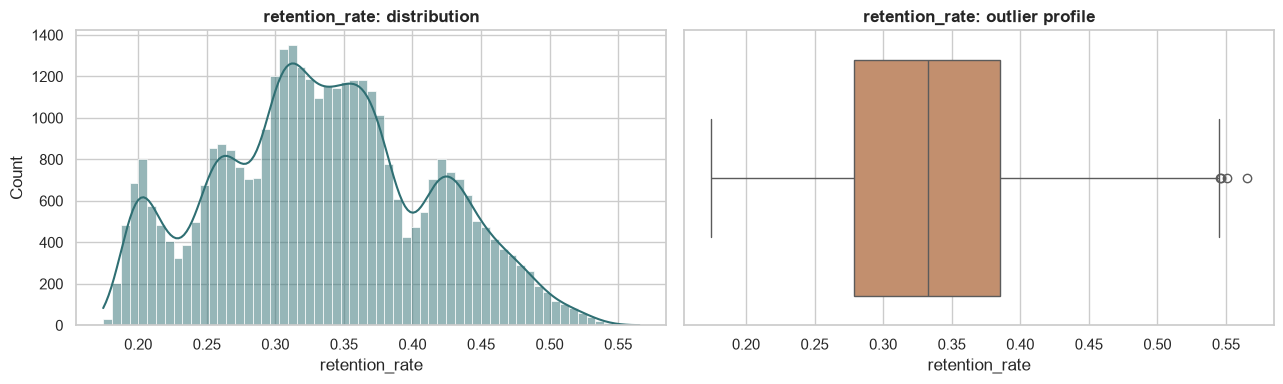

**Finding for `retention_rate`:** The distribution is **fairly balanced** with skewness **0.12** and **0.0%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

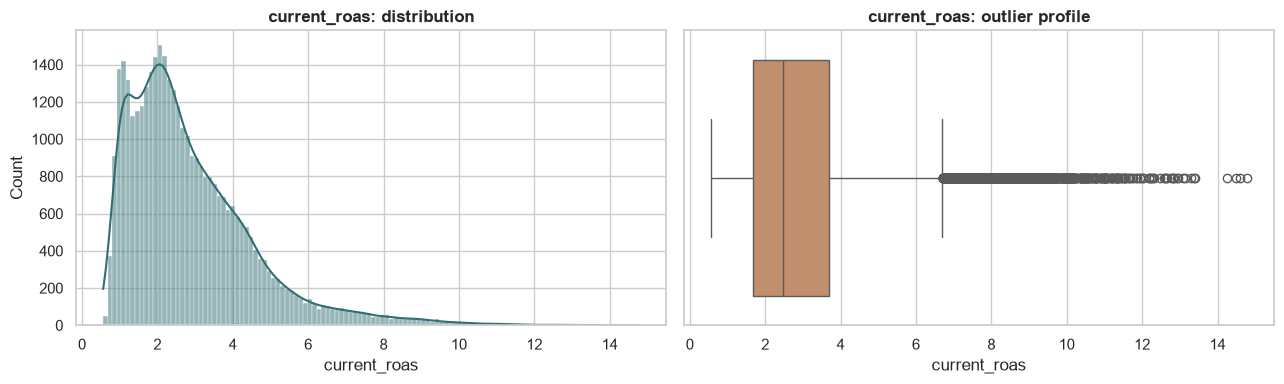

**Finding for `current_roas`:** The distribution is **right-skewed** with skewness **1.58** and **3.8%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

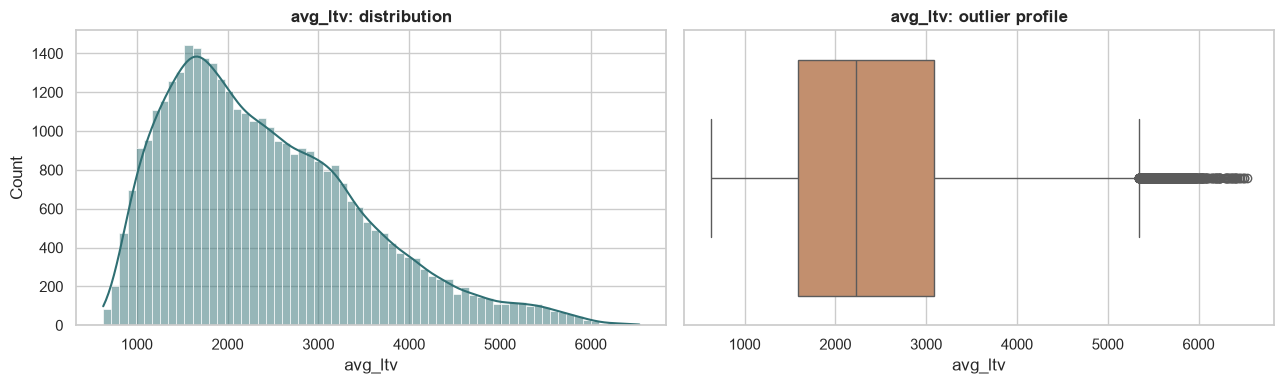

**Finding for `avg_ltv`:** The distribution is **right-skewed** with skewness **0.83** and **1.6%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

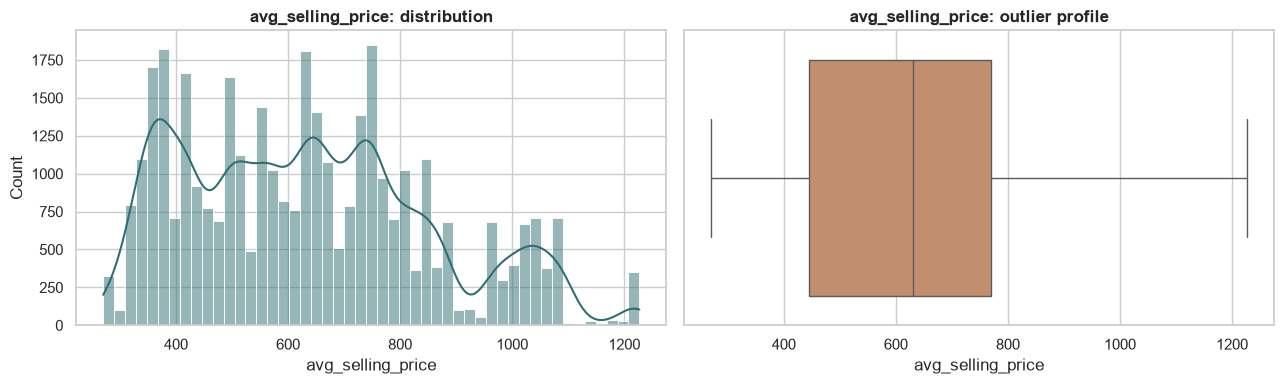

**Finding for `avg_selling_price`:** The distribution is **fairly balanced** with skewness **0.47** and **0.0%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

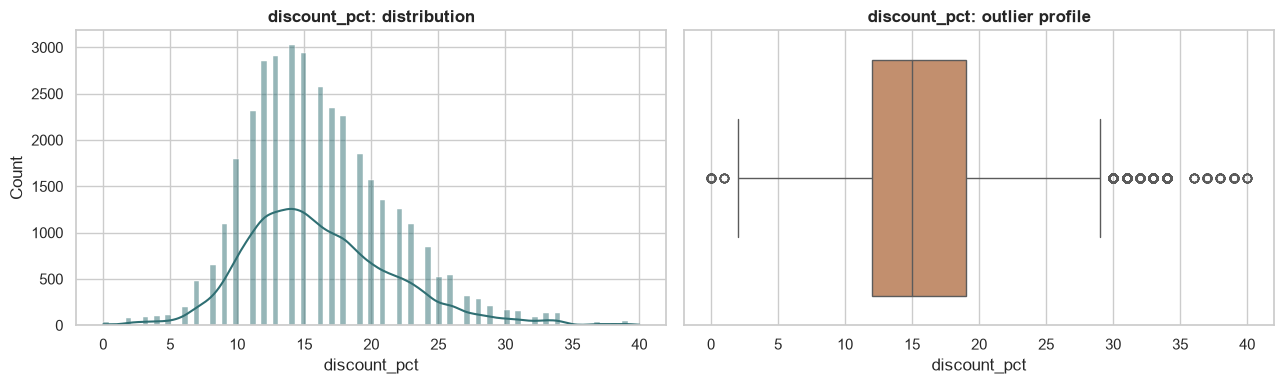

**Finding for `discount_pct`:** The distribution is **fairly balanced** with skewness **0.70** and **2.3%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

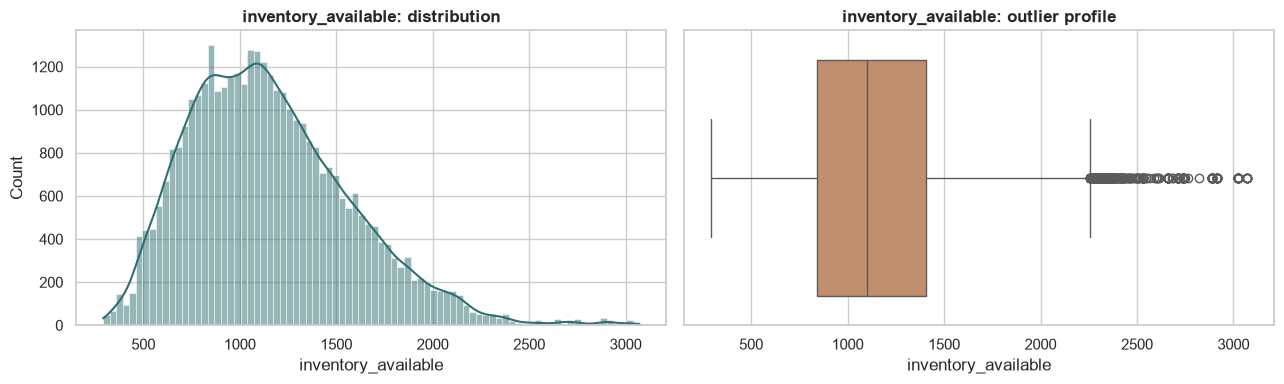

**Finding for `inventory_available`:** The distribution is **fairly balanced** with skewness **0.73** and **1.2%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

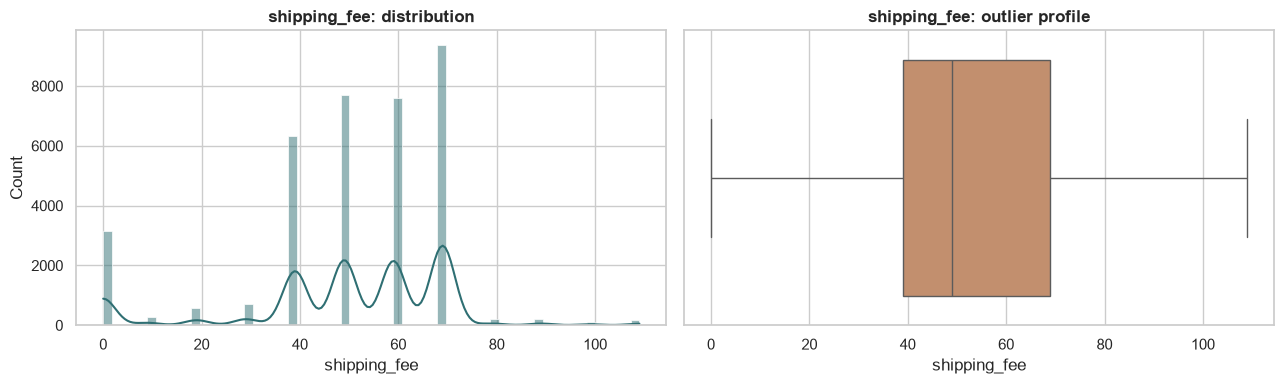

**Finding for `shipping_fee`:** The distribution is **left-skewed** with skewness **-0.95** and **0.0%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

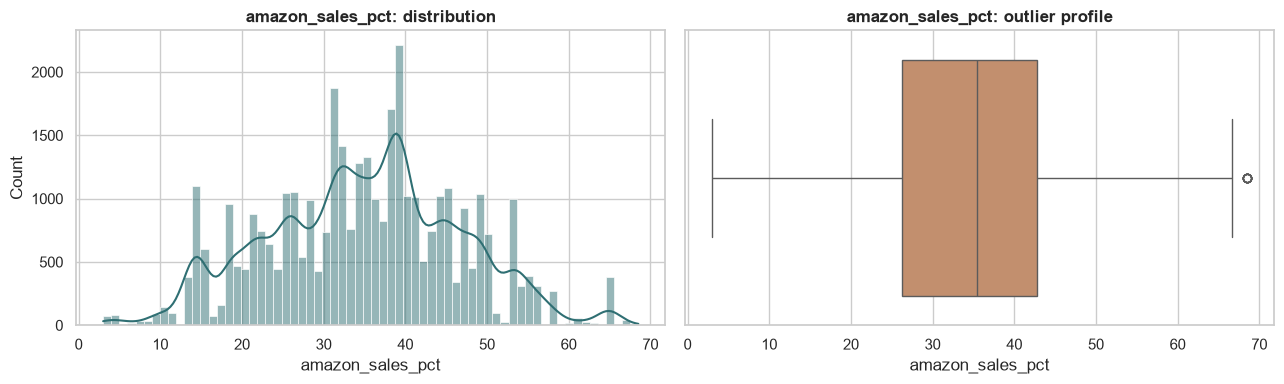

**Finding for `amazon_sales_pct`:** The distribution is **fairly balanced** with skewness **-0.00** and **0.0%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

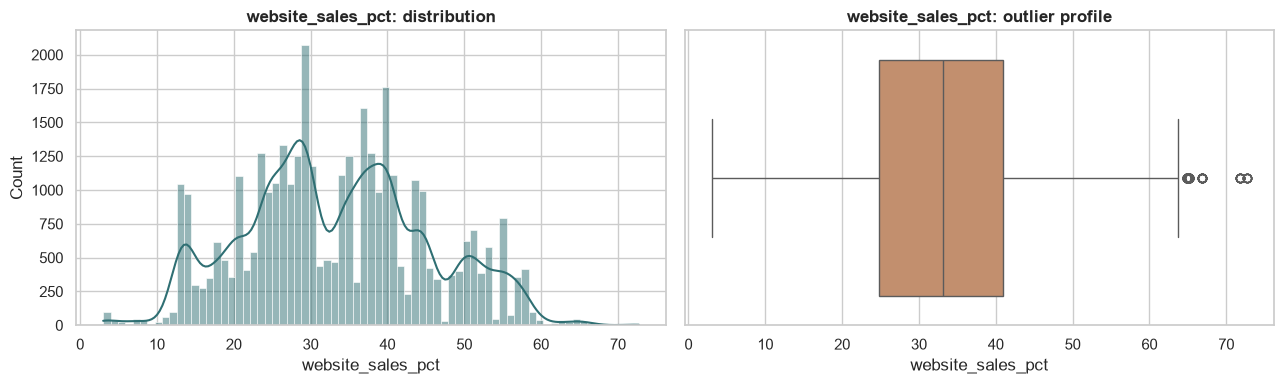

**Finding for `website_sales_pct`:** The distribution is **fairly balanced** with skewness **0.17** and **0.3%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.

In [4]:
numeric_cols = [c for c in roles["numeric"] if c not in roles["id"]]
priority_numeric = [c for c in ["revenue", "profit", "orders", "traffic", "active_users", "marketing_spend", "conversion_rate", "retention_rate", "current_roas", "avg_ltv", "avg_selling_price", "discount_pct", "inventory_available"] if c in numeric_cols]
plot_numeric = list(dict.fromkeys(priority_numeric + numeric_cols))[:16]
summary_stats = df[plot_numeric].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
summary_stats["missing_%"] = df[plot_numeric].isna().mean() * 100
summary_stats["skewness"] = df[plot_numeric].skew(numeric_only=True)
summary_stats["outlier_%_iqr"] = [iqr_outlier_mask(df[c]).mean() * 100 for c in plot_numeric]
display(summary_stats)

for col in plot_numeric:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color="#2F6F73")
    axes[0].set_title(f"{col}: distribution")
    sns.boxplot(x=df[col], ax=axes[1], color="#D08C60")
    axes[1].set_title(f"{col}: outlier profile")
    plt.tight_layout()
    plt.show()
    skew = df[col].skew()
    direction = "right-skewed" if skew > .75 else "left-skewed" if skew < -.75 else "fairly balanced"
    note(f"**Finding for `{col}`:** The distribution is **{direction}** with skewness **{skew:,.2f}** and **{iqr_outlier_mask(df[col]).mean()*100:,.1f}%** IQR outliers. **Action:** use medians and percentiles when skew is high, and investigate extreme values before treating them as errors.")

## 4. Product, Category, and Brand Performance

### Category Performance

,category,revenue,profit,orders,traffic,marketing_spend,conversion_rate,retention_rate,avg_ltv,current_roas,revenue_share_%,profit_margin_%,computed_roas
2,Skincare,"418,982,538.0100","118,411,340.0000",609441,43580444,100826016,0.0506,0.4055,"3,283.7718",4.3745,54.3294,28.2616,4.1555
1,Makeup,"174,517,760.3800","8,364,129.1700",376043,37787010,87348148,0.0353,0.2621,"2,049.6573",2.0479,22.6297,4.7927,1.9980
0,Haircare,"177,689,739.4600","-2,777,218.2200",415988,36255192,84327690,0.0412,0.3346,"1,920.7510",2.1634,23.0410,-1.5630,2.1071


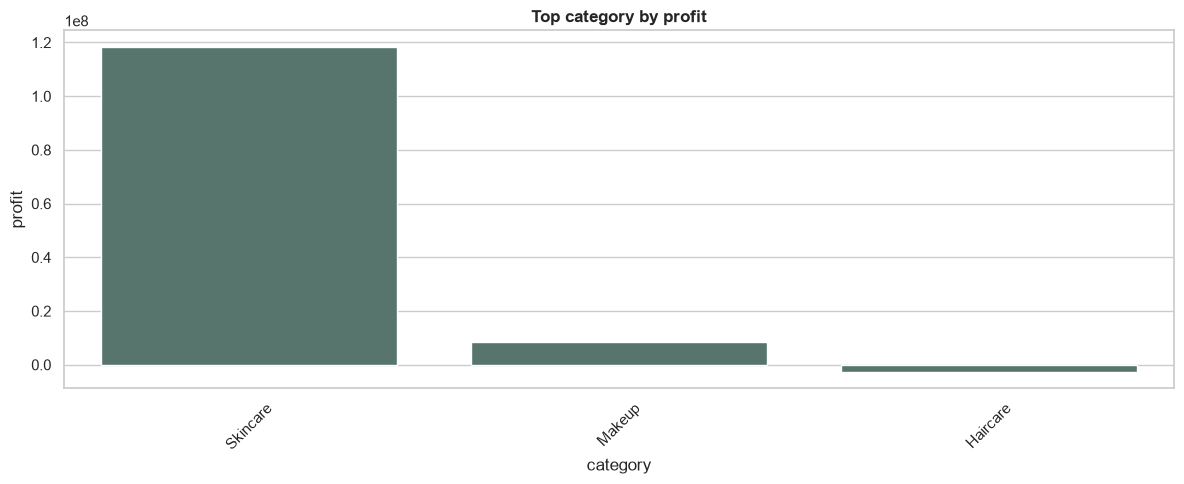

**Finding:** `Skincare` leads this view by **profit** (revenue=418,982,538.01; profit=118,411,340.00; orders=609,441.00; conversion_rate=0.05; retention_rate=0.41; avg_ltv=3,283.77). **Action:** protect availability and profitable traffic for winners, and diagnose high-revenue but weak-margin segments before scaling.

### Subcategory Performance

,subcategory,revenue,profit,orders,traffic,marketing_spend,conversion_rate,retention_rate,avg_ltv,current_roas,revenue_share_%,profit_margin_%,computed_roas
1,Serum,"418,982,538.0100","118,411,340.0000",609441,43580444,100826016,0.0506,0.4055,"3,283.7718",4.3745,54.3294,28.2616,4.1555
0,Lipstick,"174,517,760.3800","8,364,129.1700",376043,37787010,87348148,0.0353,0.2621,"2,049.6573",2.0479,22.6297,4.7927,1.9980
2,Shampoo,"177,689,739.4600","-2,777,218.2200",415988,36255192,84327690,0.0412,0.3346,"1,920.7510",2.1634,23.0410,-1.5630,2.1071


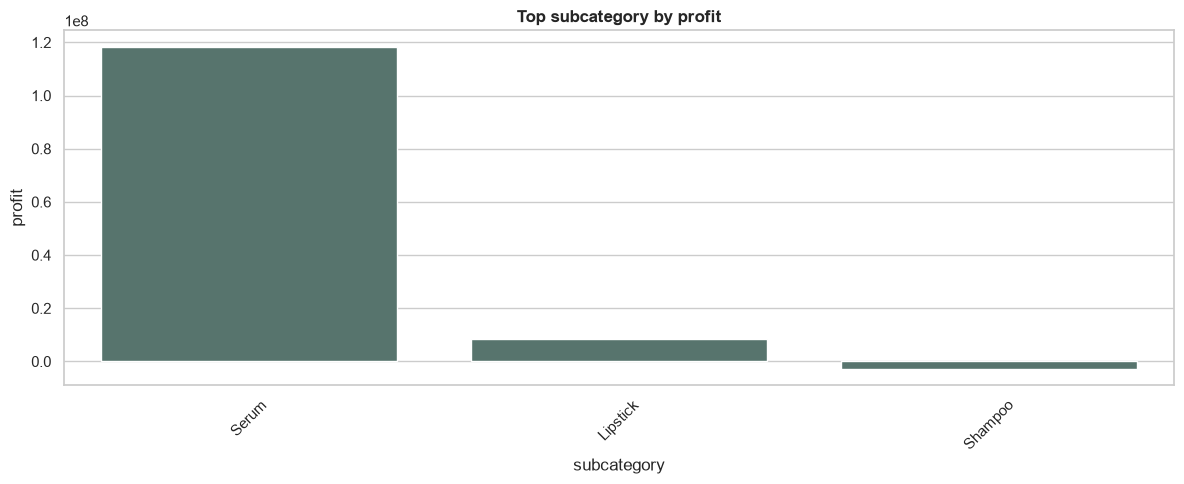

**Finding:** `Serum` leads this view by **profit** (revenue=418,982,538.01; profit=118,411,340.00; orders=609,441.00; conversion_rate=0.05; retention_rate=0.41; avg_ltv=3,283.77). **Action:** protect availability and profitable traffic for winners, and diagnose high-revenue but weak-margin segments before scaling.

### Brand Performance

,brand,revenue,profit,orders,traffic,marketing_spend,conversion_rate,retention_rate,avg_ltv,current_roas,revenue_share_%,profit_margin_%,computed_roas
2,The Derma Co,"374,803,164.6900","77,240,048.3900",636634,49862062,113563847,0.0449,0.3410,"2,544.2884",3.2949,48.6006,20.6082,3.3004
1,Minimalist,"171,202,243.8600","25,683,587.3000",303923,27082678,61998446,0.0395,0.3239,"2,522.0986",2.7004,22.1997,15.0019,2.7614
0,Mamaearth,"225,184,629.3000","21,074,615.2600",460915,40677906,96939561,0.0412,0.3340,"2,203.4775",2.4431,29.1996,9.3588,2.3229


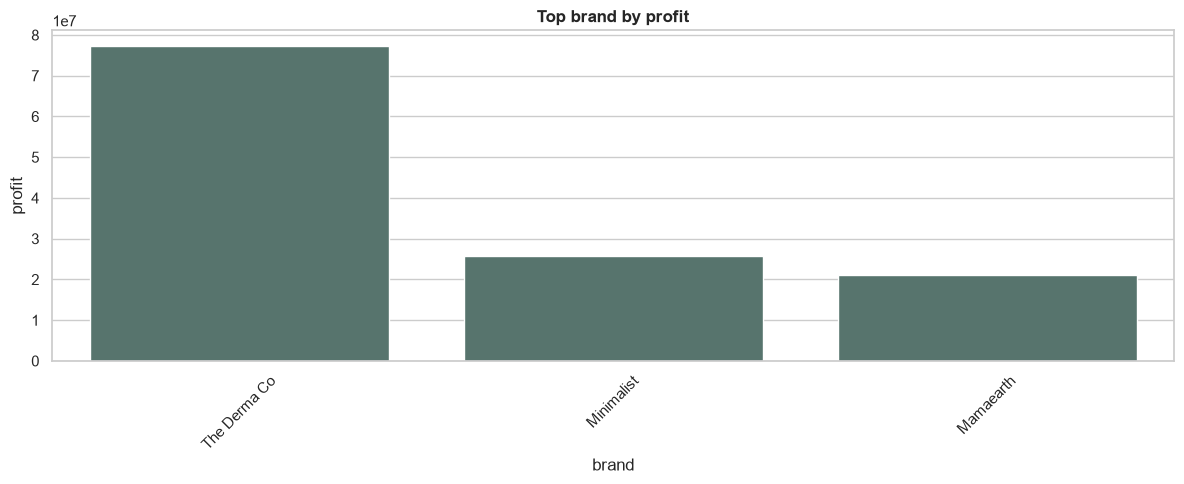

**Finding:** `The Derma Co` leads this view by **profit** (revenue=374,803,164.69; profit=77,240,048.39; orders=636,634.00; conversion_rate=0.04; retention_rate=0.34; avg_ltv=2,544.29). **Action:** protect availability and profitable traffic for winners, and diagnose high-revenue but weak-margin segments before scaling.

### Product Id Performance

,product_id,revenue,profit,orders,traffic,marketing_spend,conversion_rate,retention_rate,avg_ltv,current_roas,revenue_share_%,profit_margin_%,computed_roas
12,P013,"25,537,700.7500","11,810,141.2300",28343,1543500,4234290,0.0634,0.3684,"4,267.8712",6.1281,3.3115,46.2459,6.0312
78,P079,"17,662,541.2000","7,097,366.4000",19921,1112701,3118888,0.0622,0.4257,"4,342.6740",5.7166,2.2903,40.1832,5.6631
75,P076,"20,716,122.7700","6,362,678.8700",21141,1111559,2255771,0.0666,0.3674,"4,821.0301",9.2399,2.6863,30.7137,9.1836
36,P037,"21,039,720.8300","6,357,970.2500",22736,1610723,3158225,0.0521,0.3525,"4,165.5726",6.6658,2.7282,30.2189,6.6619
15,P016,"13,733,750.2600","6,310,003.1400",14942,930154,1767514,0.0587,0.4410,"4,341.1288",7.7726,1.7809,45.9452,7.7701
66,P067,"14,276,763.6800","5,687,001.2400",15914,1042778,1781266,0.0553,0.4322,"4,183.2548",8.0623,1.8513,39.8340,8.0150
9,P010,"14,008,244.7900","4,471,182.4900",17439,1363660,3117827,0.0458,0.4260,"3,997.9014",4.5200,1.8164,31.9182,4.4930
45,P046,"14,709,354.3200","4,431,366.2700",23668,1594020,4292858,0.0529,0.4243,"3,100.0740",3.4221,1.9074,30.1262,3.4265
21,P022,"13,029,688.7100","3,869,300.4100",23921,1357676,2581550,0.0634,0.4146,"2,626.7425",5.0661,1.6896,29.6960,5.0472
27,P028,"10,815,213.1800","3,639,599.1000",21843,1388842,2818607,0.0577,0.4853,"2,360.8329",3.8379,1.4024,33.6526,3.8371


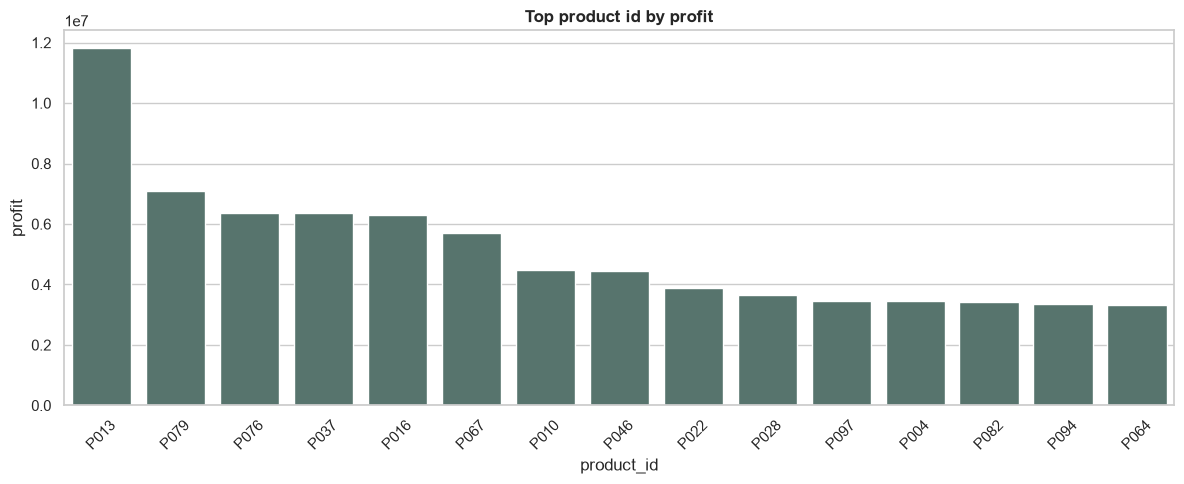

**Finding:** `P013` leads this view by **profit** (revenue=25,537,700.75; profit=11,810,141.23; orders=28,343.00; conversion_rate=0.06; retention_rate=0.37; avg_ltv=4,267.87). **Action:** protect availability and profitable traffic for winners, and diagnose high-revenue but weak-margin segments before scaling.

In [5]:
portfolio_tables = {}
for dim in ["category", "subcategory", "brand", "product_id"]:
    if dim in df.columns:
        note(f"### {dim.replace('_', ' ').title()} Performance")
        table = performance_table(df, [dim], 15)
        portfolio_tables[dim] = table
        display(table)
        y = "profit" if "profit" in table else "revenue"
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(data=table, x=dim, y=y, ax=ax, color="#52796F")
        ax.set_title(f"Top {dim.replace('_', ' ')} by {y}")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()
        top = table.iloc[0]
        evidence = "; ".join(f"{c}={top[c]:,.2f}" for c in ["revenue", "profit", "orders", "conversion_rate", "retention_rate", "avg_ltv"] if c in table)
        note(f"**Finding:** `{top[dim]}` leads this view by **{y}** ({evidence}). **Action:** protect availability and profitable traffic for winners, and diagnose high-revenue but weak-margin segments before scaling.")

## 5. Channel, Campaign, and Acquisition Effectiveness

### Sales Channel Effectiveness

,segment,avg_mix_%,estimated_revenue,estimated_profit,estimated_orders,estimated_traffic,estimated_marketing_spend,estimated_roas
1,website,33.3616,"261,688,423.0931","46,337,692.3936","462,585.7690","38,446,393.4133","88,799,489.8219",2.9470
0,amazon,34.8824,"262,358,316.1112","37,614,323.2754","489,574.6791","41,671,391.2119","96,347,129.9740",2.7231
2,nykaa,20.1481,"158,779,550.2135","25,797,604.9585","286,025.3891","23,875,719.2225","55,475,923.3169",2.8621
3,mobile_app,11.6080,"88,363,748.4321","14,248,630.3225","163,286.1628","13,629,142.1523","31,879,310.8872",2.7718


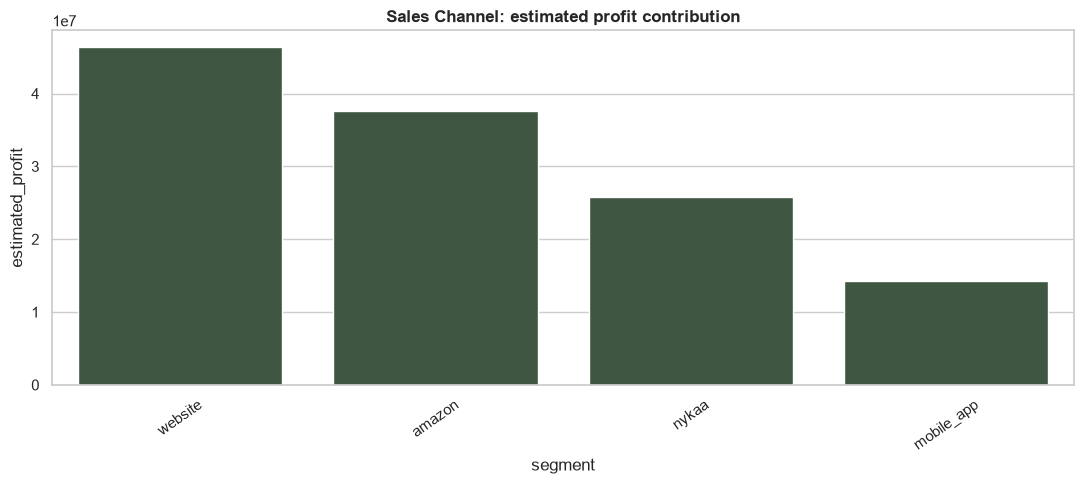

**Finding:** `website` has the strongest estimated profit contribution. **Action:** compare its conversion and retention quality before scaling investment; channels with high contribution but weak ROAS should be optimized before they receive more budget.

### Campaign Effectiveness

,segment,avg_mix_%,estimated_revenue,estimated_profit,estimated_orders,estimated_traffic,estimated_marketing_spend,estimated_roas
0,search,34.7941,"281,252,055.3359","48,490,763.6085","501,353.9136","41,325,251.8378","96,030,893.0752",2.9288
1,social,36.3833,"262,249,175.7005","36,867,386.0054","492,124.9617","42,381,406.9192","97,852,949.2746",2.6800
2,email,17.6810,"142,687,006.8792","24,555,278.4188","254,223.7141","20,869,769.9416","48,739,626.7143",2.9275
3,affiliate,11.1415,"85,001,799.9344","14,084,822.9173","153,769.4106","13,046,217.3014","29,878,384.9359",2.8449


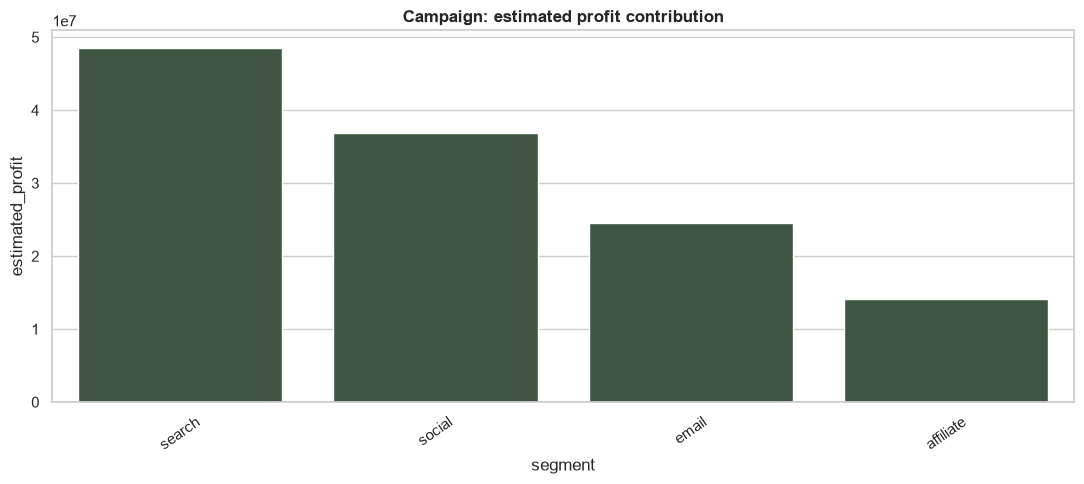

**Finding:** `search` has the strongest estimated profit contribution. **Action:** compare its conversion and retention quality before scaling investment; channels with high contribution but weak ROAS should be optimized before they receive more budget.

### Acquisition Source Effectiveness

,segment,avg_mix_%,estimated_revenue,estimated_profit,estimated_orders,estimated_traffic,estimated_marketing_spend,estimated_roas
0,google,36.1164,"295,313,453.8867","52,093,959.6185","523,272.9655","42,850,301.4252","99,759,483.6830",2.9603
1,instagram,24.6753,"181,334,066.1453","28,113,763.8561","329,872.7862","28,654,862.1081","66,212,999.3124",2.7386
4,organic,13.8191,"105,922,203.1367","16,046,779.9319","196,266.4592","16,361,053.4467","37,752,495.4472",2.8057
2,facebook,12.7554,"95,495,210.6706","14,549,686.2256","176,404.4169","14,971,315.3721","34,813,085.5494",2.7431
3,email,7.7885,"56,856,199.3909","8,021,943.9283","107,418.7466","9,047,213.4318","20,729,937.8223",2.7427
5,referral,4.8454,"36,268,904.6198","5,172,117.3897","68,236.6256","5,737,900.2161","13,233,852.1857",2.7406


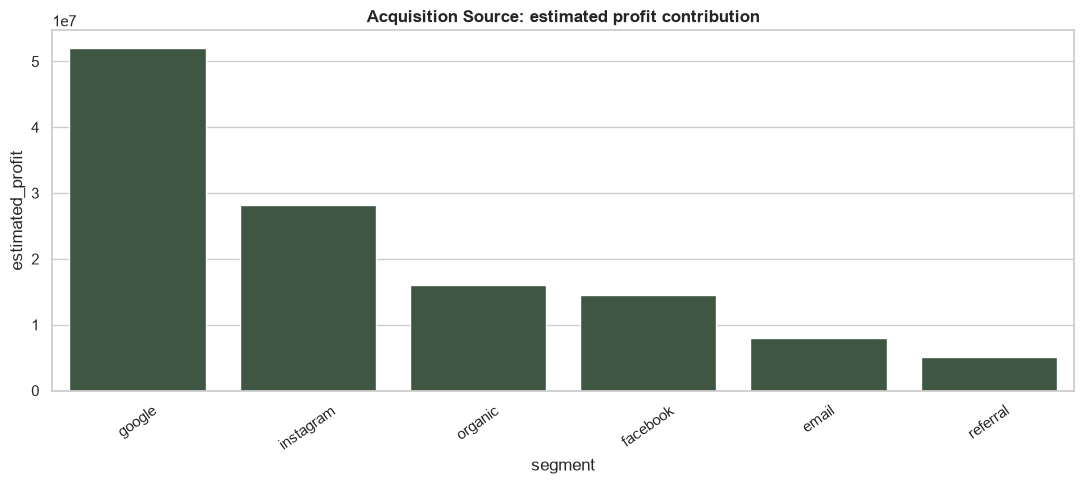

**Finding:** `google` has the strongest estimated profit contribution. **Action:** compare its conversion and retention quality before scaling investment; channels with high contribution but weak ROAS should be optimized before they receive more budget.

In [6]:
channel_cols = [c for c in df.columns if c.endswith("_sales_pct") or c.startswith("sales_mix_")]
campaign_cols = [c for c in df.columns if c.endswith("_campaign_pct") or c.startswith("campaign_mix_")]
source_cols = [c for c in df.columns if c.endswith("_source_pct") or c.startswith("acq_mix_")]
note("### Sales Channel Effectiveness")
channel_effectiveness = contribution_analysis(df, channel_cols, "Sales Channel")
note("### Campaign Effectiveness")
campaign_effectiveness = contribution_analysis(df, campaign_cols, "Campaign")
note("### Acquisition Source Effectiveness")
source_effectiveness = contribution_analysis(df, source_cols, "Acquisition Source")

## 6. Time-Series Trends with Rolling Averages

In [7]:
date_cols = roles["date"]
trend_kpis = [c for c in ["revenue", "profit", "orders", "traffic", "active_users", "marketing_spend", "conversion_rate", "retention_rate", "current_roas"] if c in df.columns]
if date_cols and trend_kpis:
    date_col = date_cols[0]
    daily = df.groupby(date_col)[trend_kpis].sum(numeric_only=True).sort_index()
    for c in ["conversion_rate", "retention_rate", "current_roas"]:
        if c in df.columns:
            daily[c] = df.groupby(date_col)[c].mean().sort_index()
    window = 7 if len(daily) < 90 else 14
    display(daily.describe().T)
    for col in trend_kpis:
        fig, ax = plt.subplots(figsize=(13, 4.5))
        ax.plot(daily.index, daily[col], alpha=.35, label="Actual", color="#6C757D")
        ax.plot(daily.index, daily[col].rolling(window, min_periods=max(2, window // 3)).mean(), label=f"{window}-period rolling average", color="#B56576", linewidth=2.5)
        ax.set_title(f"{col}: trend and rolling average")
        ax.legend()
        plt.tight_layout()
        plt.show()
        r = daily[col].rolling(window, min_periods=max(2, window // 3)).mean().dropna()
        change = (r.iloc[-1] - r.iloc[0]) / abs(r.iloc[0]) * 100 if len(r) and r.iloc[0] else np.nan
        note(f"**Finding for `{col}`:** Rolling performance changed by **{change:,.1f}%** over the observed period. **Action:** line this movement up with pricing, inventory, campaign, and experiment timelines to separate demand changes from operational causes.")
else:
    note("No usable date column and KPI combination was found for time-series analysis.")

No usable date column and KPI combination was found for time-series analysis.

## 7. Pearson and Spearman Correlation Heatmaps

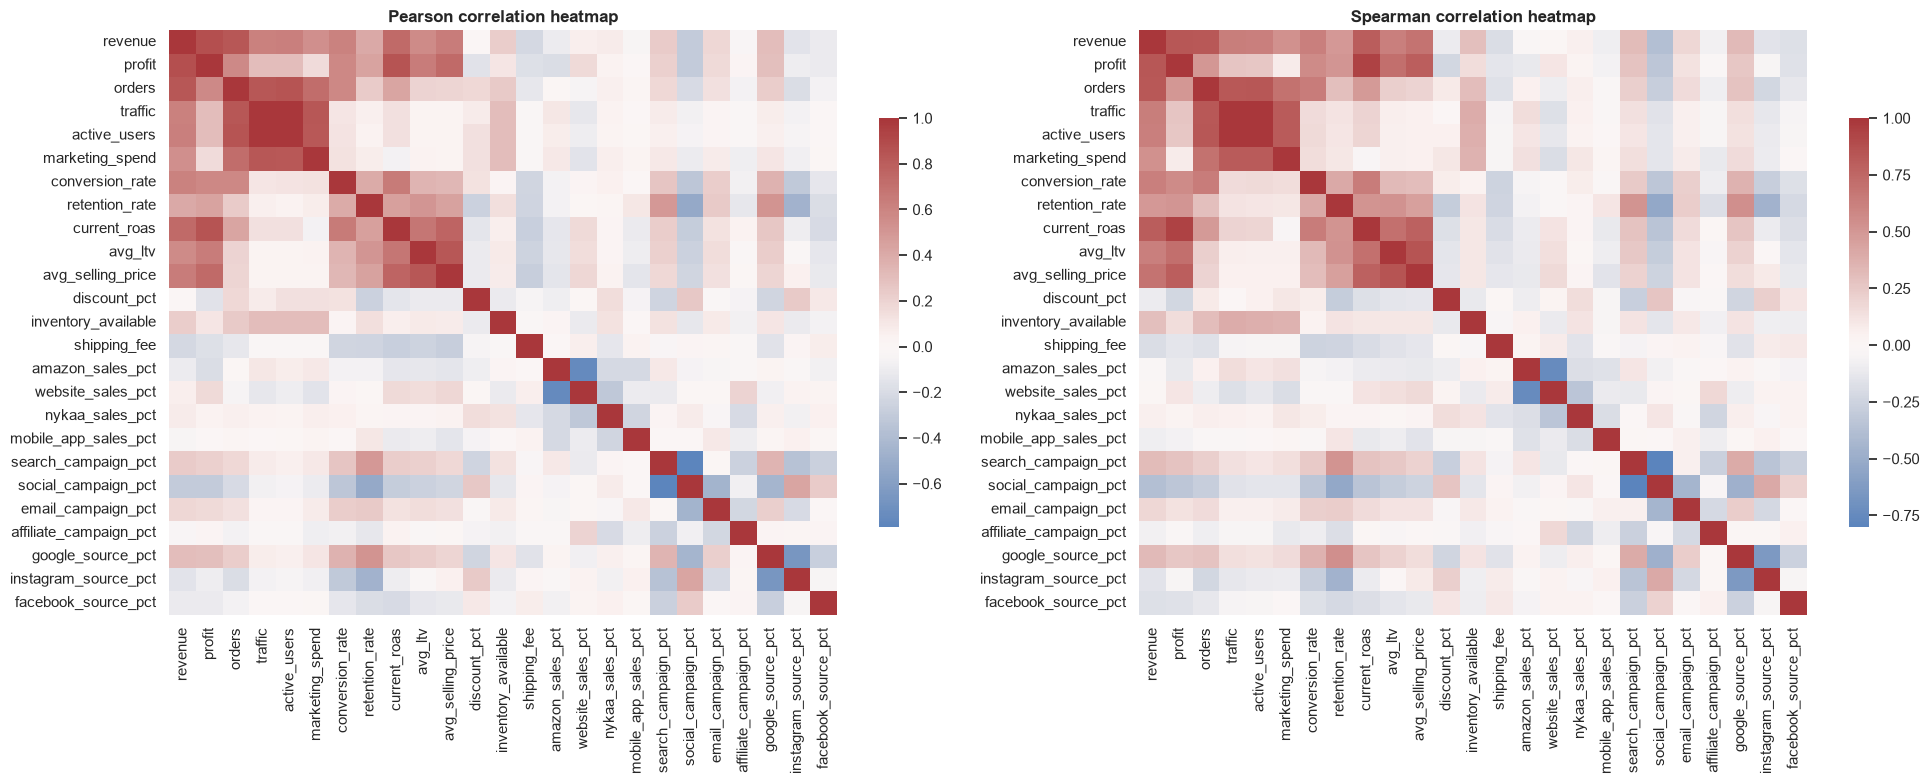

**Interpretation:** Pearson highlights linear relationships, while Spearman captures rank-based monotonic relationships. Strong correlations are prioritization evidence, not causality.

In [8]:
corr_cols = list(dict.fromkeys(priority_numeric + [c for c in numeric_cols if df[c].nunique(dropna=True) > 2]))[:25]
if len(corr_cols) >= 2:
    pearson = df[corr_cols].corr("pearson")
    spearman = df[corr_cols].corr("spearman")
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    sns.heatmap(pearson, cmap="vlag", center=0, ax=axes[0], cbar_kws={"shrink": .7})
    axes[0].set_title("Pearson correlation heatmap")
    sns.heatmap(spearman, cmap="vlag", center=0, ax=axes[1], cbar_kws={"shrink": .7})
    axes[1].set_title("Spearman correlation heatmap")
    plt.tight_layout()
    plt.show()
    note("**Interpretation:** Pearson highlights linear relationships, while Spearman captures rank-based monotonic relationships. Strong correlations are prioritization evidence, not causality.")
else:
    note("Not enough numeric columns for correlation heatmaps.")

## 8. Revenue, Profit, Conversion, and Retention Driver Analysis

### Drivers of revenue

,base_feature,spearman_corr,mutual_information,linear_coefficient_abs,rf_importance,mutual_information_score,linear_coefficient_abs_score,rf_importance_score,composite_driver_score
23,profit,0.8311,0.7981,"7,072.0305",0.7839,1.0000,0.9667,1.0000,0.9889
21,orders,0.8283,0.7626,"7,315.3742",0.1436,0.9555,1.0000,0.1831,0.7129
4,avg_selling_price,0.6886,0.5822,"1,628.0389",0.0334,0.7295,0.2226,0.0427,0.3316
9,current_roas,0.8051,0.5205,"2,450.8062",0.0033,0.6522,0.3350,0.0042,0.3305
0,active_users,0.6330,0.3518,"3,871.8932",0.0045,0.4408,0.5293,0.0058,0.3253
18,marketing_spend,0.5301,0.2258,"4,416.7559",0.0160,0.2829,0.6038,0.0204,0.3024
29,subcategory,0.0000,0.4122,"1,724.2612",0.0000,0.5165,0.2357,0.0000,0.2507
6,category,0.0000,0.4122,"1,724.2612",0.0000,0.5165,0.2357,0.0000,0.2507
14,facebook_source_pct,-0.1729,0.5587,5.5139,0.0003,0.7001,0.0008,0.0004,0.2338
13,email_source_pct,-0.1487,0.5400,27.1469,0.0003,0.6766,0.0037,0.0004,0.2269


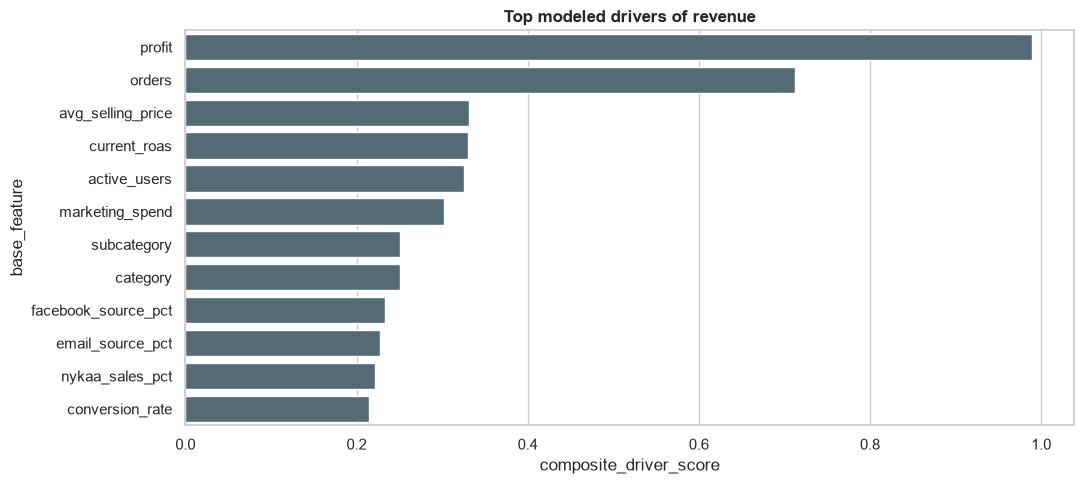

**Finding:** The strongest modeled drivers of `revenue` are **profit, orders, avg_selling_price, current_roas, active_users**. **Action:** use these as diagnostic levers, then validate with experiments or holdout analysis before large pricing or budget changes.

### Drivers of profit

,base_feature,spearman_corr,mutual_information,linear_coefficient_abs,rf_importance,mutual_information_score,linear_coefficient_abs_score,rf_importance_score,composite_driver_score
25,revenue,0.8311,0.7981,"9,088.5098",0.6525,0.7644,1.0000,1.0000,0.9215
9,current_roas,0.9373,1.0441,832.4617,0.2576,1.0000,0.0916,0.3948,0.4955
4,avg_selling_price,0.7982,0.8080,80.8588,0.0090,0.7739,0.0089,0.0138,0.2655
14,facebook_source_pct,-0.1618,0.7581,117.2775,0.0010,0.7261,0.0129,0.0015,0.2468
13,email_source_pct,-0.1532,0.7498,80.1982,0.0022,0.7181,0.0088,0.0034,0.2434
23,referral_source_pct,-0.0345,0.6876,178.8999,0.0026,0.6585,0.0197,0.0040,0.2274
22,organic_source_pct,-0.0624,0.6985,29.6261,0.0006,0.6690,0.0033,0.0009,0.2244
1,affiliate_campaign_pct,-0.0149,0.6696,141.4062,0.0046,0.6413,0.0156,0.0070,0.2213
16,instagram_source_pct,-0.0454,0.6789,13.8747,0.0024,0.6502,0.0015,0.0037,0.2185
20,nykaa_sales_pct,0.0345,0.6639,45.6011,0.0012,0.6358,0.0050,0.0018,0.2142


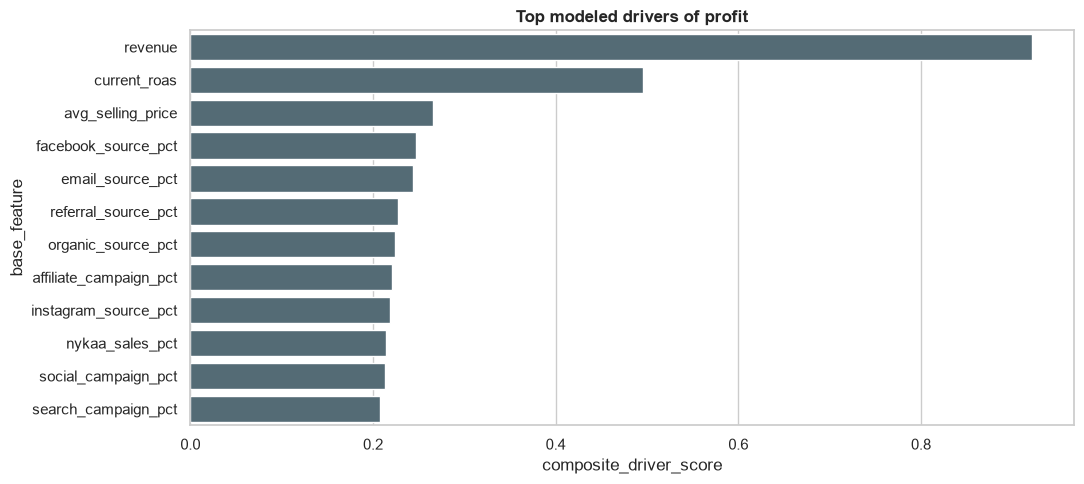

**Finding:** The strongest modeled drivers of `profit` are **revenue, current_roas, avg_selling_price, facebook_source_pct, email_source_pct**. **Action:** use these as diagnostic levers, then validate with experiments or holdout analysis before large pricing or budget changes.

### Drivers of conversion_rate

,base_feature,spearman_corr,mutual_information,linear_coefficient_abs,rf_importance,mutual_information_score,linear_coefficient_abs_score,rf_importance_score,composite_driver_score
20,orders,0.6458,0.2761,0.0162,0.2332,0.4169,1.0000,0.6485,0.6885
8,current_roas,0.6421,0.2973,0.0069,0.3596,0.4489,0.4273,1.0000,0.6254
0,active_users,0.1649,0.0213,0.0153,0.0817,0.0321,0.9457,0.2273,0.4017
12,email_source_pct,0.0041,0.6574,0.0001,0.0245,0.9927,0.0043,0.0682,0.3551
15,instagram_source_pct,-0.2829,0.6622,0.0005,0.0113,1.0000,0.0293,0.0313,0.3535
4,avg_selling_price,0.3049,0.6209,0.0011,0.0180,0.9375,0.0663,0.0501,0.3513
25,revenue,0.6308,0.2743,0.0095,0.0084,0.4143,0.5853,0.0235,0.3410
21,organic_source_pct,0.0747,0.6288,0.0002,0.0067,0.9494,0.0107,0.0188,0.3263
19,nykaa_sales_pct,0.0774,0.6179,0.0001,0.0127,0.9330,0.0065,0.0355,0.3250
23,referral_source_pct,-0.0027,0.6199,0.0003,0.0074,0.9360,0.0184,0.0206,0.3250


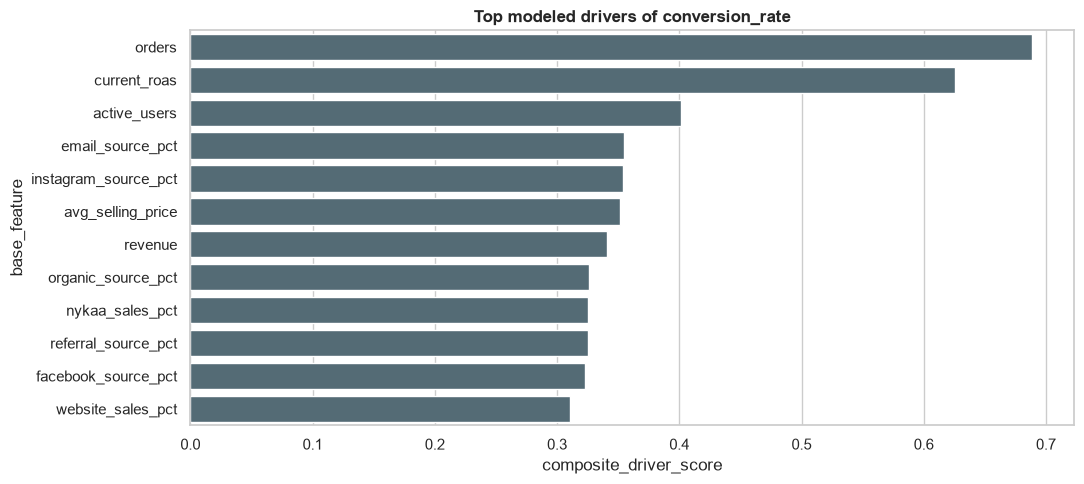

**Finding:** The strongest modeled drivers of `conversion_rate` are **orders, current_roas, active_users, email_source_pct, instagram_source_pct**. **Action:** use these as diagnostic levers, then validate with experiments or holdout analysis before large pricing or budget changes.

### Drivers of retention_rate

,base_feature,spearman_corr,mutual_information,linear_coefficient_abs,rf_importance,mutual_information_score,linear_coefficient_abs_score,rf_importance_score,composite_driver_score
29,subcategory,0.0000,0.7842,0.0603,0.3193,0.4873,0.7504,1.0000,0.7459
6,category,0.0000,0.7804,0.0603,0.2704,0.4849,0.7504,0.8470,0.6941
4,avg_selling_price,0.4573,1.2919,0.0187,0.0524,0.8027,0.2333,0.1642,0.4001
25,revenue,0.4953,0.2354,0.0804,0.0009,0.1463,1.0000,0.0029,0.3831
22,organic_source_pct,0.1605,1.5460,0.0037,0.0336,0.9607,0.0463,0.1052,0.3707
12,email_campaign_pct,0.2294,1.5285,0.0001,0.0503,0.9498,0.0017,0.1574,0.3696
16,instagram_source_pct,-0.4600,1.5140,0.0073,0.0176,0.9408,0.0909,0.0552,0.3623
13,email_source_pct,0.0143,1.6093,0.0032,0.0093,1.0000,0.0396,0.0290,0.3562
20,nykaa_sales_pct,0.0225,1.5323,0.0016,0.0302,0.9521,0.0195,0.0947,0.3554
14,facebook_source_pct,-0.2156,1.5603,0.0013,0.0229,0.9695,0.0165,0.0718,0.3526


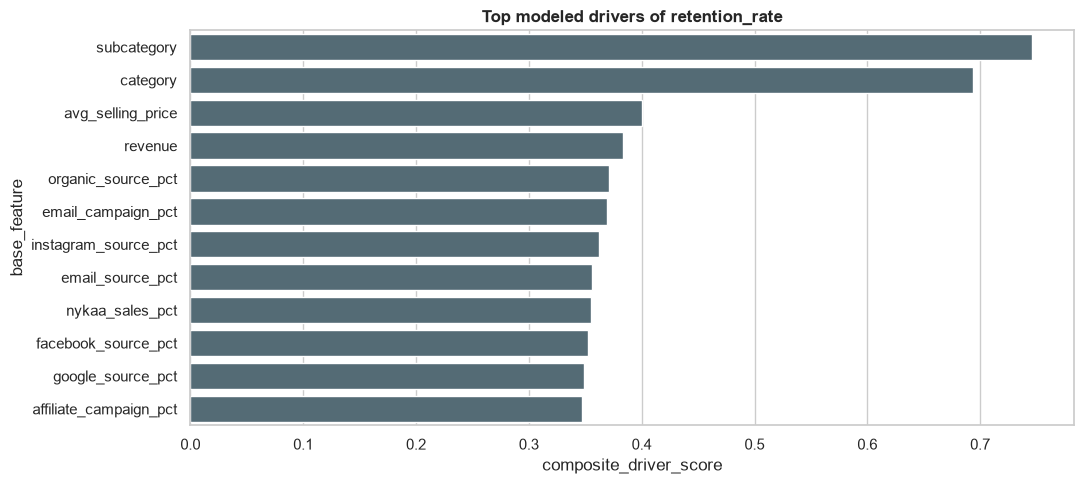

**Finding:** The strongest modeled drivers of `retention_rate` are **subcategory, category, avg_selling_price, revenue, organic_source_pct**. **Action:** use these as diagnostic levers, then validate with experiments or holdout analysis before large pricing or budget changes.

In [9]:
def driver_analysis(data, target):
    if target not in data.columns or data[target].nunique(dropna=True) < 5:
        return pd.DataFrame()
    blocked = {target}
    features = []
    for c in data.columns:
        if c in blocked or c in roles["json_like"] or c in roles["date"] or c.startswith("next_"):
            continue
        if c in roles["id"] and data[c].nunique() > 100:
            continue
        if data[c].nunique(dropna=True) <= 1:
            continue
        features.append(c)
    X = data[features].copy()
    y = pd.to_numeric(data[target], errors="coerce")
    mask = y.notna()
    X, y = X.loc[mask], y.loc[mask]
    if len(X) > 5000:
        idx = X.sample(5000, random_state=RANDOM_STATE).index
        X, y = X.loc[idx], y.loc[idx]
    num = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
    cat = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c]) and X[c].nunique(dropna=True) <= 30]
    X = X[num + cat]
    if len(X.columns) < 2 or len(X) < 30:
        return pd.DataFrame()
    pre = ColumnTransformer([
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num),
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore", max_categories=15))]), cat),
    ])
    Xt = pre.fit_transform(X)
    names = list(num)
    if cat:
        names += pre.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(cat).tolist()
    mi = mutual_info_regression(Xt, y, random_state=RANDOM_STATE)
    lin = LinearRegression().fit(Xt, y)
    rf = RandomForestRegressor(n_estimators=120, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1).fit(Xt, y)
    rows = []
    corr = {c: data[[c, target]].corr("spearman").iloc[0, 1] for c in num}
    for name, mi_score, coef, imp in zip(names, mi, lin.coef_, rf.feature_importances_):
        base = name if name in num else name.split("_")[0]
        rows.append({"base_feature": base, "spearman_corr": corr.get(name, np.nan), "mutual_information": mi_score, "linear_coefficient_abs": abs(coef), "rf_importance": imp})
    out = pd.DataFrame(rows).groupby("base_feature", as_index=False).sum(numeric_only=True)
    for metric in ["mutual_information", "linear_coefficient_abs", "rf_importance"]:
        m = out[metric].max()
        out[f"{metric}_score"] = out[metric] / m if m else 0
    out["composite_driver_score"] = out[["mutual_information_score", "linear_coefficient_abs_score", "rf_importance_score"]].mean(axis=1)
    out.attrs["rf_r2_in_sample"] = r2_score(y, rf.predict(Xt))
    return out.sort_values("composite_driver_score", ascending=False)


driver_results = {}
for target in [c for c in ["revenue", "profit", "conversion_rate", "retention_rate"] if c in df.columns]:
    note(f"### Drivers of {target}")
    res = driver_analysis(df, target)
    driver_results[target] = res
    if res.empty:
        note(f"Not enough usable features to model `{target}`.")
        continue
    display(res.head(15))
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(data=res.head(12), x="composite_driver_score", y="base_feature", ax=ax, color="#4F6D7A")
    ax.set_title(f"Top modeled drivers of {target}")
    plt.tight_layout()
    plt.show()
    note(f"**Finding:** The strongest modeled drivers of `{target}` are **{', '.join(res.head(5)['base_feature'].astype(str))}**. **Action:** use these as diagnostic levers, then validate with experiments or holdout analysis before large pricing or budget changes.")

## 9. Root-Cause Analysis for Drops in Revenue, Profit, Conversion, Retention, and Traffic

In [10]:
root_cause_outputs = {}
if date_cols:
    date_col = date_cols[0]
    drivers = [c for c in ["marketing_spend", "traffic", "active_users", "orders", "avg_selling_price", "discount_pct", "shipping_fee", "inventory_available", "current_roas", "conversion_rate", "retention_rate"] if c in df.columns]
    for kpi in [c for c in ["revenue", "profit", "conversion_rate", "retention_rate", "traffic"] if c in df.columns]:
        use_cols = [c for c in drivers if c != kpi]
        daily = df.groupby(date_col).agg({c: "mean" for c in [kpi] + use_cols}).sort_index()
        if len(daily) < 10:
            continue
        roll = daily[kpi].rolling(7, min_periods=3).mean()
        pct = roll.pct_change()
        worst_date = pct.idxmin()
        before = daily.loc[:worst_date].tail(14).head(7)
        during = daily.loc[:worst_date].tail(7)
        rows = []
        for c in use_cols:
            b, d = before[c].mean(), during[c].mean()
            rows.append({"driver": c, "before_avg": b, "during_drop_avg": d, "change_abs": d - b, "change_%": (d - b) / abs(b) * 100 if b else np.nan})
        table = pd.DataFrame(rows).sort_values("change_%", key=lambda s: s.abs(), ascending=False)
        root_cause_outputs[kpi] = (table, {"date": worst_date, "drop_pct": pct.loc[worst_date] * 100})
        note(f"### Root-cause hypotheses for {kpi}")
        note(f"Largest rolling drop detected around **{pd.to_datetime(worst_date).date()}**: **{pct.loc[worst_date]*100:,.1f}%**.")
        display(table.head(10))
        fig, ax = plt.subplots(figsize=(10, 4.5))
        sns.barplot(data=table.head(8), x="change_%", y="driver", ax=ax, color="#C1666B")
        ax.axvline(0, color="black", linewidth=1)
        ax.set_title(f"Largest driver shifts around {kpi} drop")
        plt.tight_layout()
        plt.show()
        note("**Interpretation:** These are root-cause hypotheses, not proof. **Action:** audit campaign changes, price moves, stockouts, tracking changes, and operational incidents around the detected window.")
else:
    note("No date column was found, so root-cause drop analysis cannot be run.")

No date column was found, so root-cause drop analysis cannot be run.

## 10. Experiment Analysis: Before, During, and After Lift

In [11]:
if not experiment_candidates:
    note("**No experiment dataset was found in the current working tree.** To activate this section, add a CSV with fields such as `experiment_id`, `product_id`, `start_date`, `end_date`, and `primary_metric`, then rerun the notebook.")
else:
    exp_name = experiment_candidates[0]
    exp = loaded[exp_name].copy()
    exp["start_date"] = pd.to_datetime(exp.get("start_date"), errors="coerce")
    exp["end_date"] = pd.to_datetime(exp.get("end_date"), errors="coerce")
    note(f"Experiment dataset used: `{exp_name}`")
    display(exp.head())
    results = []
    if date_cols:
        date_col = date_cols[0]
        for _, row in exp.dropna(subset=["start_date", "end_date"]).iterrows():
            metric = clean_name(row.get("primary_metric", "revenue"))
            if metric not in df.columns:
                metric = "revenue" if "revenue" in df.columns else None
            if metric is None:
                continue
            product_mask = pd.Series(True, index=df.index)
            if "product_id" in exp.columns and "product_id" in df.columns and pd.notna(row.get("product_id")):
                product_mask = df["product_id"].astype(str).eq(str(row.get("product_id")))
            start, end = row["start_date"], row["end_date"]
            duration = max((end - start).days + 1, 1)
            before = df.loc[product_mask & df[date_col].between(start - pd.Timedelta(days=duration), start - pd.Timedelta(days=1)), metric].mean()
            during = df.loc[product_mask & df[date_col].between(start, end), metric].mean()
            after = df.loc[product_mask & df[date_col].between(end + pd.Timedelta(days=1), end + pd.Timedelta(days=duration)), metric].mean()
            results.append({
                "experiment_id": row.get("experiment_id", row.name),
                "product_id": row.get("product_id", "all"),
                "experiment_type": row.get("experiment_type", "unknown"),
                "metric": metric,
                "before_avg": before,
                "during_avg": during,
                "after_avg": after,
                "during_lift_%": (during - before) / abs(before) * 100 if pd.notna(before) and before else np.nan,
                "after_lift_%": (after - before) / abs(before) * 100 if pd.notna(before) and before else np.nan,
                "reported_result": row.get("result", np.nan),
                "confidence": row.get("confidence", np.nan),
            })
    exp_results = pd.DataFrame(results).sort_values("during_lift_%", ascending=False)
    display(exp_results.head(30))
    if len(exp_results):
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(data=exp_results.head(15), x="experiment_id", y="during_lift_%", hue="metric", dodge=False, ax=ax)
        ax.axhline(0, color="black", linewidth=1)
        ax.set_title("Experiment KPI lift during test window")
        ax.tick_params(axis="x", rotation=45)
        plt.tight_layout()
        plt.show()
        note("**Interpretation:** Positive during-lift plus sustained after-lift suggests rollout potential. Temporary lift without after-lift suggests novelty, promotion pull-forward, or channel pressure.")

**No experiment dataset was found in the current working tree.** To activate this section, add a CSV with fields such as `experiment_id`, `product_id`, `start_date`, `end_date`, and `primary_metric`, then rerun the notebook.

## 11. Top 10 Business Recommendations Ranked by Impact

In [12]:
recommendations = []

def add_rec(title, evidence, action, score):
    recommendations.append({"rank_basis_score": float(score) if pd.notna(score) else 0, "recommendation": title, "quantitative_evidence": evidence, "business_action": action})

if "product_id" in df.columns and {"revenue", "profit"} <= set(df.columns):
    prod = performance_table(df, ["product_id"], 50)
    if len(prod):
        top = prod.iloc[0]
        add_rec(f"Protect and scale top profit product `{top.product_id}`", f"Profit {top['profit']:,.0f}; revenue {top['revenue']:,.0f}; margin {top.get('profit_margin_%', np.nan):,.1f}%.", "Prioritize inventory, merchandising, and high-quality traffic for this product.", abs(top["profit"]))
        weak = prod[(prod["revenue"] > prod["revenue"].quantile(.75)) & (prod["profit_margin_%"] < prod["profit_margin_%"].median())] if "profit_margin_%" in prod else pd.DataFrame()
        if len(weak):
            row = weak.iloc[0]
            add_rec(f"Fix margin leakage in high-revenue product `{row.product_id}`", f"Revenue {row['revenue']:,.0f} but margin {row['profit_margin_%']:,.1f}% trails portfolio median.", "Review discounting, shipping fee, acquisition cost, and fulfillment cost before adding more demand.", row["revenue"] * max(0, (prod["profit_margin_%"].median() - row["profit_margin_%"]) / 100))

for dim in ["category", "brand"]:
    if dim in portfolio_tables and len(portfolio_tables[dim]):
        row = portfolio_tables[dim].iloc[0]
        add_rec(f"Use `{row[dim]}` as the benchmark {dim}", f"Revenue {row['revenue']:,.0f}; profit {row['profit']:,.0f}; revenue share {row.get('revenue_share_%', np.nan):,.1f}%.", f"Compare pricing, campaign mix, retention, and availability of weaker {dim}s against this benchmark.", abs(row.get("profit", row.get("revenue", 0))))

for label, tab in [("channel", channel_effectiveness), ("campaign", campaign_effectiveness), ("source", source_effectiveness)]:
    if isinstance(tab, pd.DataFrame) and len(tab):
        row = tab.iloc[0]
        add_rec(f"Reallocate budget toward strongest {label} `{row.segment}`", f"Estimated profit {row.get('estimated_profit', np.nan):,.0f}; estimated revenue {row.get('estimated_revenue', np.nan):,.0f}; estimated ROAS {row.get('estimated_roas', np.nan):,.2f}.", "Scale only where incremental conversion and retention remain healthy; cap spend where ROAS deteriorates.", abs(row.get("estimated_profit", row.get("estimated_revenue", 0))))

for target, res in driver_results.items():
    if isinstance(res, pd.DataFrame) and len(res):
        top = res.iloc[0]
        add_rec(f"Run controlled tests on `{top.base_feature}` to improve {target}", f"Composite driver score {top.composite_driver_score:,.2f}; RF importance {top.rf_importance:,.2f}; MI {top.mutual_information:,.2f}.", "Move from observational EDA to A/B, geo, or holdout testing before committing broad changes.", top.composite_driver_score * (df[target].sum() if target in ["revenue", "profit"] else len(df)))

for kpi, (table, event) in root_cause_outputs.items():
    if len(table):
        row = table.iloc[0]
        add_rec(f"Investigate {kpi} drop around {pd.to_datetime(event['date']).date()}", f"Rolling {kpi} dropped {event['drop_pct']:,.1f}%; largest concurrent driver shift was {row.driver} ({row['change_%']:,.1f}%).", "Audit campaign changes, pricing, inventory, tracking, and operational incidents for the detected window.", abs(event["drop_pct"]) * 100)

rec_df = pd.DataFrame(recommendations).sort_values("rank_basis_score", ascending=False).drop_duplicates("recommendation").head(10).reset_index(drop=True)
rec_df.insert(0, "rank", np.arange(1, len(rec_df) + 1))
display(rec_df[["rank", "recommendation", "quantitative_evidence", "business_action", "rank_basis_score"]])

,rank,recommendation,quantitative_evidence,business_action,rank_basis_score
0,1,Run controlled tests on `profit` to improve re...,Composite driver score 0.99; RF importance 0.7...,"Move from observational EDA to A/B, geo, or ho...","762,638,902.5689"
1,2,Use `Skincare` as the benchmark category,"Revenue 418,982,538; profit 118,411,340; reven...","Compare pricing, campaign mix, retention, and ...","118,411,340.0000"
2,3,Run controlled tests on `revenue` to improve p...,Composite driver score 0.92; RF importance 0.6...,"Move from observational EDA to A/B, geo, or ho...","114,259,698.4047"
3,4,Use `The Derma Co` as the benchmark brand,"Revenue 374,803,165; profit 77,240,048; revenu...","Compare pricing, campaign mix, retention, and ...","77,240,048.3900"
4,5,Reallocate budget toward strongest source `goo...,"Estimated profit 52,093,960; estimated revenue...",Scale only where incremental conversion and re...,"52,093,959.6185"
5,6,Reallocate budget toward strongest campaign `s...,"Estimated profit 48,490,764; estimated revenue...",Scale only where incremental conversion and re...,"48,490,763.6085"
6,7,Reallocate budget toward strongest channel `we...,"Estimated profit 46,337,692; estimated revenue...",Scale only where incremental conversion and re...,"46,337,692.3936"
7,8,Protect and scale top profit product `P013`,"Profit 11,810,141; revenue 25,537,701; margin ...","Prioritize inventory, merchandising, and high-...","11,810,141.2300"
8,9,Fix margin leakage in high-revenue product `P007`,"Revenue 14,309,936 but margin 22.2% trails por...","Review discounting, shipping fee, acquisition ...","327,800.1370"
9,10,Run controlled tests on `subcategory` to impro...,Composite driver score 0.75; RF importance 0.3...,"Move from observational EDA to A/B, geo, or ho...","27,225.0373"


## 12. Executive Summary with Quantitative Evidence

In [13]:
lines = [f"- Primary dataset: `{main_dataset_name}` with **{len(df):,} rows** and **{df.shape[1]:,} columns**."]
if date_cols:
    d = date_cols[0]
    lines.append(f"- Time coverage: **{pd.to_datetime(df[d]).min().date()}** to **{pd.to_datetime(df[d]).max().date()}** using `{d}`.")
for kpi in ["revenue", "profit", "orders", "traffic", "marketing_spend"]:
    if kpi in df.columns:
        lines.append(f"- Total {kpi.replace('_', ' ')}: **{df[kpi].sum():,.0f}**.")
for kpi in ["conversion_rate", "retention_rate", "current_roas", "avg_ltv"]:
    if kpi in df.columns:
        lines.append(f"- Average {kpi.replace('_', ' ')}: **{df[kpi].mean():,.4f}**.")
if {"profit", "revenue"} <= set(df.columns) and df["revenue"].sum():
    lines.append(f"- Overall profit margin: **{df['profit'].sum() / df['revenue'].sum() * 100:,.1f}%**.")
lines.append(f"- Data-quality watchlist: **{len(roles['constant'])} constant** and **{len(roles['near_constant'])} near-constant** columns; **{df.duplicated().sum():,} duplicate rows**.")
if len(rec_df):
    lines.append(f"- Highest-ranked recommendation: **{rec_df.iloc[0]['recommendation']}** supported by {rec_df.iloc[0]['quantitative_evidence']}")
if experiment_candidates:
    lines.append(f"- Experiment analysis ran using detected dataset(s): {', '.join(experiment_candidates)}.")
else:
    lines.append("- Experiment metadata was not present in the current branch, so before/during/after lift analysis is documented as unavailable.")
display(Markdown("\n".join(lines)))
note("**Executive interpretation:** Convert the strongest EDA signals into measured actions: protect profitable portfolio winners, repair high-revenue/low-margin leakage, optimize budget toward profitable channels, and validate top modeled drivers through controlled tests.")

- Primary dataset: `backend\temporal_dataset.csv` with **36,500 rows** and **38 columns**.
- Total revenue: **771,190,038**.
- Total profit: **123,998,251**.
- Total orders: **1,401,472**.
- Total traffic: **117,622,646**.
- Total marketing spend: **272,501,854**.
- Average conversion rate: **0.0425**.
- Average retention rate: **0.3348**.
- Average current roas: **2.8771**.
- Average avg ltv: **2,426.7172**.
- Overall profit margin: **16.1%**.
- Data-quality watchlist: **0 constant** and **0 near-constant** columns; **0 duplicate rows**.
- Highest-ranked recommendation: **Run controlled tests on `profit` to improve revenue** supported by Composite driver score 0.99; RF importance 0.78; MI 0.80.
- Experiment metadata was not present in the current branch, so before/during/after lift analysis is documented as unavailable.

**Executive interpretation:** Convert the strongest EDA signals into measured actions: protect profitable portfolio winners, repair high-revenue/low-margin leakage, optimize budget toward profitable channels, and validate top modeled drivers through controlled tests.